In [26]:
import pandas as pd
import os
from glob import glob
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import json
import random
from xgboost import XGBClassifier

Data Preprocessing

In [2]:
directory_buggy = "D:\\ICSE_Dataset\\CSVAllBuggy"
directory_correct = "D:\\ICSE_Dataset\\CSVAllCorrect"

In [4]:
# data_points = []

# def convert_tensor_to_bool(tensor_str):
#     if isinstance(tensor_str, str):
#         return 'True' in tensor_str
#     elif isinstance(tensor_str, bool):
#         return tensor_str
#     elif isinstance(tensor_str, int):
#         return bool(tensor_str)
#     return False

# columns_to_delete = []
# def process_directory(directory, label):
#     data_points = []
#     for filename in os.listdir(directory):
#         if filename.endswith('.csv'):
#             file_path = os.path.join(directory, filename)
#             df = pd.read_csv(file_path)
#             if 'dying_relu' in df.columns:
#                 df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
#             df = df.drop(columns=columns_to_delete, errors='ignore')
#             data_point = df.mean().to_frame().T
#             data_point['label'] = label
#             data_points.append(data_point)
#     return data_points

# data_points_correct = process_directory(directory_correct, 'Correct')
# data_points_hyperparameter = process_directory(directory_buggy, 'Hyperparameter')
# min_samples = min(len(data_points_correct), len(data_points_hyperparameter))
# data_points_balanced = data_points_correct[:min_samples] + data_points_hyperparameter[:min_samples]
# df_combined = pd.concat(data_points_balanced, ignore_index=True)
# print(df_combined.head())
# output_file = "D:\\ICSE_Dataset\\hyperparameter_correct_data.csv"
# df_combined.to_csv(output_file, index=False)
# print(f"Combined balanced data saved to {output_file}")

C:\Users\sigma\AppData\Local\Temp\ipykernel_15272\4138252092.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_combined = pd.concat(data_points_balanced, ignore_index=True)


   epoch  train_loss  train_acc  val_loss   val_acc  large_weight_count  \
0   24.5    0.023571   0.993023  0.019086  1.000000                 0.0   
1   24.5    0.249584   0.530000  0.262938  0.400000                 0.0   
2   24.5    0.654575   0.597500  0.699320  0.598125                 0.0   
3   24.5    0.589356   0.685469  0.787796  0.422812                 0.0   
4   24.5    0.664158   0.640625  0.710822  0.533906                 0.0   

   acc_gap_too_big  loss_oscillation  dying_relu  gradient_vanish  ...  \
0             0.02              0.10        0.06             0.98  ...   
1             1.00              0.00        0.00             0.00  ...   
2             0.02              0.18        0.00             0.00  ...   
3             0.92              0.32        0.00             0.00  ...   
4             0.76              0.46        0.00             0.00  ...   

   gradient_median  adjusted_lr  mean_activation  std_activation  mean_grad  \
0         0.007774     0.

In [41]:
import os
import pandas as pd

data_points = []

def convert_tensor_to_bool(tensor_str):
    if isinstance(tensor_str, str):
        return 'True' in tensor_str
    elif isinstance(tensor_str, bool):
        return tensor_str
    elif isinstance(tensor_str, int):
        return bool(tensor_str)
    return False

columns_to_delete = []

def process_directory(directory, label_filter):
    data_points = []
    for filename in os.listdir(directory):
        if filename.endswith('.csv') and any(label in filename for label in label_filter):
            label = next(label for label in label_filter if label in filename)
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            if 'dying_relu' in df.columns:
                df['dying_relu'] = df['dying_relu'].apply(lambda x: convert_tensor_to_bool(x))
            df = df.drop(columns=columns_to_delete, errors='ignore')
            data_point = df.mean().to_frame().T
            data_point['label'] = label
            data_points.append(data_point)
    return data_points

label_filter = ['Activation', 'Layer', 'Loss', 'Optimization']
data_points_correct = process_directory(directory_buggy, label_filter)
data_points_hyperparameter = process_directory(directory_buggy, ['Hyperparameter'])
min_samples = min(len(data_points_correct), len(data_points_hyperparameter))
data_points_balanced = data_points_correct[:min_samples] + data_points_hyperparameter[:min_samples]
df_combined = pd.concat(data_points_balanced, ignore_index=True)
print(df_combined.head())

output_file = "D:\\ICSE_Dataset\\hyperparameter_correct_data.csv"
df_combined.to_csv(output_file, index=False)
print(f"Combined balanced data saved to {output_file}")
df_combined

   epoch  train_loss  train_acc  val_loss  val_acc  large_weight_count  \
0   24.5    2.302334   0.103912  2.303556   0.1095                 0.0   
1   24.5    2.302162   0.106308  2.302621   0.1010                 0.0   
2   24.5    2.302400   0.102262  2.303584   0.1020                 0.0   
3   24.5    2.302297   0.103786  2.303293   0.1030                 0.0   
4   24.5    2.302155   0.106588  2.303741   0.1005                 0.0   

   acc_gap_too_big  loss_oscillation  dying_relu  gradient_vanish  ...  \
0              0.0               0.0         1.0              1.0  ...   
1              0.0               0.0         1.0              1.0  ...   
2              0.0               0.0         1.0              1.0  ...   
3              0.0               0.0         1.0              1.0  ...   
4              0.0               0.0         1.0              1.0  ...   

   gradient_median  adjusted_lr  mean_activation  std_activation  mean_grad  \
0         0.000007     0.000179

,epoch,train_loss,train_acc,val_loss,val_acc,large_weight_count,acc_gap_too_big,loss_oscillation,dying_relu,gradient_vanish,...,gradient_median,adjusted_lr,mean_activation,std_activation,mean_grad,std_grad,cpu_utilization,gpu_memory_utilization,memory_usage,label
0,24.5,2.302334,0.103912,2.303556,0.1095,0.00,0.0,0.00,1.0,1.00,...,0.000007,0.000179,0.020234,0.001234,-0.000003,0.003347,3.340,355.931885,9.050,Layer
1,24.5,2.302162,0.106308,2.302621,0.1010,0.00,0.0,0.00,1.0,1.00,...,0.000006,0.000179,0.020180,0.001563,-0.000005,0.003122,3.378,377.343975,9.054,Layer
2,24.5,2.302400,0.102262,2.303584,0.1020,0.00,0.0,0.00,1.0,1.00,...,0.000029,0.000179,0.020049,0.000854,0.000004,0.003099,3.350,378.677734,9.110,Layer
3,24.5,2.302297,0.103786,2.303293,0.1030,0.00,0.0,0.00,1.0,1.00,...,0.000019,0.000179,0.020149,0.001255,0.000001,0.003438,3.652,378.677734,10.824,Layer
4,24.5,2.302155,0.106588,2.303741,0.1005,0.00,0.0,0.00,1.0,1.00,...,0.000015,0.000179,0.020198,0.001738,0.000008,0.003124,3.524,378.677734,10.972,Layer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,24.5,3350.279006,0.000000,1547.008201,0.0000,242.94,0.0,0.98,1.0,0.00,...,451.899300,0.001791,9.640529,0.000000,-8.755601,0.000000,27.952,1.149170,14.600,Hyperparameter
5138,24.5,1461.936873,0.000000,1394.617703,0.0000,40.98,0.0,0.98,1.0,0.00,...,4.962247,0.001791,11.137314,0.000000,-7.469500,0.000000,27.990,1.149170,14.700,Hyperparameter
5139,24.5,1493.555571,0.000000,1392.391719,0.0000,38.98,0.0,0.98,1.0,0.00,...,6.381533,0.001791,11.196921,0.000000,-8.106470,0.000000,28.416,1.149170,14.700,Hyperparameter
5140,24.5,0.693150,0.501555,0.693206,0.4965,0.00,0.0,0.00,0.0,1.00,...,0.000415,0.000179,0.173106,0.012240,0.000904,0.001270,1.862,11.561909,7.216,Hyperparameter


In [42]:
# now change the label names to 0 and 1 - Hyperparameter to 1 and all others to 0
df_combined['label'] = df_combined['label'].apply(lambda x: 1 if x == 'Hyperparameter' else 0)
df_combined

,epoch,train_loss,train_acc,val_loss,val_acc,large_weight_count,acc_gap_too_big,loss_oscillation,dying_relu,gradient_vanish,...,gradient_median,adjusted_lr,mean_activation,std_activation,mean_grad,std_grad,cpu_utilization,gpu_memory_utilization,memory_usage,label
0,24.5,2.302334,0.103912,2.303556,0.1095,0.00,0.0,0.00,1.0,1.00,...,0.000007,0.000179,0.020234,0.001234,-0.000003,0.003347,3.340,355.931885,9.050,0
1,24.5,2.302162,0.106308,2.302621,0.1010,0.00,0.0,0.00,1.0,1.00,...,0.000006,0.000179,0.020180,0.001563,-0.000005,0.003122,3.378,377.343975,9.054,0
2,24.5,2.302400,0.102262,2.303584,0.1020,0.00,0.0,0.00,1.0,1.00,...,0.000029,0.000179,0.020049,0.000854,0.000004,0.003099,3.350,378.677734,9.110,0
3,24.5,2.302297,0.103786,2.303293,0.1030,0.00,0.0,0.00,1.0,1.00,...,0.000019,0.000179,0.020149,0.001255,0.000001,0.003438,3.652,378.677734,10.824,0
4,24.5,2.302155,0.106588,2.303741,0.1005,0.00,0.0,0.00,1.0,1.00,...,0.000015,0.000179,0.020198,0.001738,0.000008,0.003124,3.524,378.677734,10.972,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,24.5,3350.279006,0.000000,1547.008201,0.0000,242.94,0.0,0.98,1.0,0.00,...,451.899300,0.001791,9.640529,0.000000,-8.755601,0.000000,27.952,1.149170,14.600,1
5138,24.5,1461.936873,0.000000,1394.617703,0.0000,40.98,0.0,0.98,1.0,0.00,...,4.962247,0.001791,11.137314,0.000000,-7.469500,0.000000,27.990,1.149170,14.700,1
5139,24.5,1493.555571,0.000000,1392.391719,0.0000,38.98,0.0,0.98,1.0,0.00,...,6.381533,0.001791,11.196921,0.000000,-8.106470,0.000000,28.416,1.149170,14.700,1
5140,24.5,0.693150,0.501555,0.693206,0.4965,0.00,0.0,0.00,0.0,1.00,...,0.000415,0.000179,0.173106,0.012240,0.000904,0.001270,1.862,11.561909,7.216,1


In [43]:
data = df_combined.copy()
data

,epoch,train_loss,train_acc,val_loss,val_acc,large_weight_count,acc_gap_too_big,loss_oscillation,dying_relu,gradient_vanish,...,gradient_median,adjusted_lr,mean_activation,std_activation,mean_grad,std_grad,cpu_utilization,gpu_memory_utilization,memory_usage,label
0,24.5,2.302334,0.103912,2.303556,0.1095,0.00,0.0,0.00,1.0,1.00,...,0.000007,0.000179,0.020234,0.001234,-0.000003,0.003347,3.340,355.931885,9.050,0
1,24.5,2.302162,0.106308,2.302621,0.1010,0.00,0.0,0.00,1.0,1.00,...,0.000006,0.000179,0.020180,0.001563,-0.000005,0.003122,3.378,377.343975,9.054,0
2,24.5,2.302400,0.102262,2.303584,0.1020,0.00,0.0,0.00,1.0,1.00,...,0.000029,0.000179,0.020049,0.000854,0.000004,0.003099,3.350,378.677734,9.110,0
3,24.5,2.302297,0.103786,2.303293,0.1030,0.00,0.0,0.00,1.0,1.00,...,0.000019,0.000179,0.020149,0.001255,0.000001,0.003438,3.652,378.677734,10.824,0
4,24.5,2.302155,0.106588,2.303741,0.1005,0.00,0.0,0.00,1.0,1.00,...,0.000015,0.000179,0.020198,0.001738,0.000008,0.003124,3.524,378.677734,10.972,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,24.5,3350.279006,0.000000,1547.008201,0.0000,242.94,0.0,0.98,1.0,0.00,...,451.899300,0.001791,9.640529,0.000000,-8.755601,0.000000,27.952,1.149170,14.600,1
5138,24.5,1461.936873,0.000000,1394.617703,0.0000,40.98,0.0,0.98,1.0,0.00,...,4.962247,0.001791,11.137314,0.000000,-7.469500,0.000000,27.990,1.149170,14.700,1
5139,24.5,1493.555571,0.000000,1392.391719,0.0000,38.98,0.0,0.98,1.0,0.00,...,6.381533,0.001791,11.196921,0.000000,-8.106470,0.000000,28.416,1.149170,14.700,1
5140,24.5,0.693150,0.501555,0.693206,0.4965,0.00,0.0,0.00,0.0,1.00,...,0.000415,0.000179,0.173106,0.012240,0.000904,0.001270,1.862,11.561909,7.216,1


In [44]:
# unique label count 
data['label'].value_counts()

label
0    2571
1    2571
Name: count, dtype: int64

Start from here if you have the CSV file for the combined dataframe - named as hyperparameter_correct_data

In [45]:
X = df_combined.drop(columns=['label'])
y = df_combined['label']
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.max()), axis=0)
for column in X.columns:
    if X[column].isna().sum() > 0 or np.isinf(X[column]).sum() > 0:
        X[column] = X[column].replace([np.inf, -np.inf], np.nan).fillna(X[column].mean())
    lower_quantile = X[column].quantile(0.01)
    upper_quantile = X[column].quantile(0.99)

    X[column] = X[column].clip(lower=lower_quantile, upper=upper_quantile)
X = X.apply(lambda x: x.fillna(x.mean()), axis=0)
X = X.replace([np.inf, -np.inf], np.nan).apply(lambda x: x.fillna(x.mean()), axis=0)
if X.isna().sum().sum() > 0 or np.isinf(X).sum().sum() > 0:
    print("There are still NaNs or infinite values in the DataFrame. Additional cleaning needed.")
else:
    print("Data cleaning completed successfully. No NaNs or infinite values remain.")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)


Data cleaning completed successfully. No NaNs or infinite values remain.
X_train shape:  (4113, 31)
X_test shape:  (1029, 31)
y_train shape:  (4113, 2)
y_test shape:  (1029, 2)


Feature importance 

Feature ranking:
1. feature 29 (0.166730)
2. feature 28 (0.124247)
3. feature 23 (0.123479)
4. feature 2 (0.121814)
5. feature 30 (0.103176)
6. feature 4 (0.099273)
7. feature 7 (0.058247)
8. feature 9 (0.052710)
9. feature 6 (0.047726)
10. feature 8 (0.023587)
11. feature 5 (0.015575)
12. feature 21 (0.014328)
13. feature 10 (0.008572)
14. feature 24 (0.008094)
15. feature 25 (0.006228)
16. feature 19 (0.005908)
17. feature 0 (0.004649)
18. feature 20 (0.004104)
19. feature 18 (0.004027)
20. feature 3 (0.001624)
21. feature 16 (0.001595)
22. feature 15 (0.001445)
23. feature 14 (0.000800)
24. feature 22 (0.000747)
25. feature 13 (0.000623)
26. feature 26 (0.000275)
27. feature 27 (0.000239)
28. feature 1 (0.000177)
29. feature 12 (0.000000)
30. feature 11 (0.000000)
31. feature 17 (0.000000)


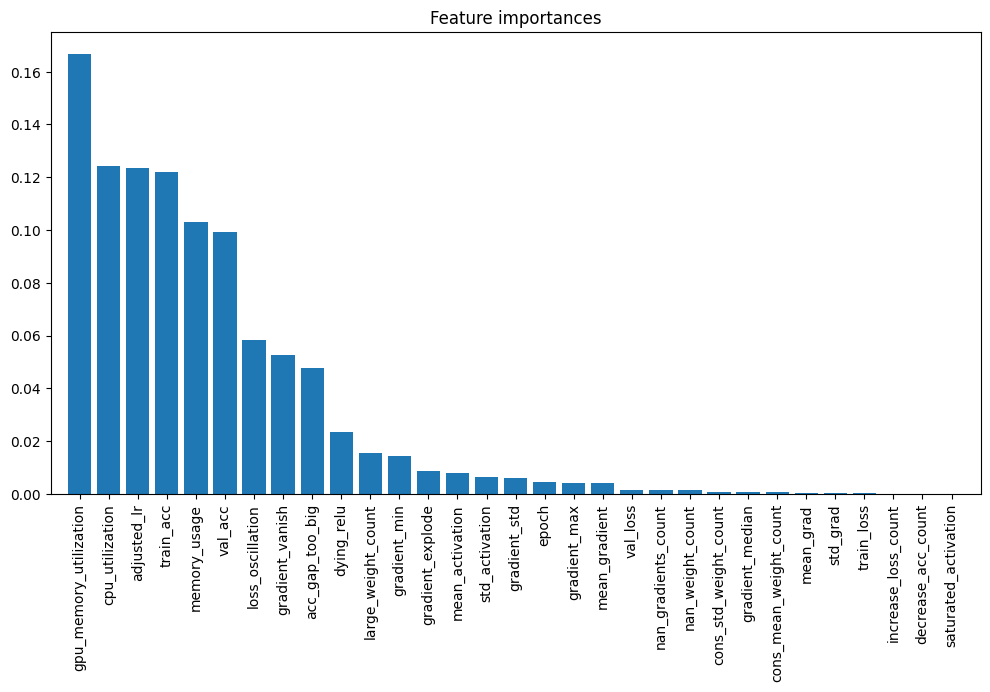

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
importances = clf.feature_importances_

indices = np.argsort(importances)[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))


feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()

In [47]:
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

Feature ranking:
1. feature 29 (0.080175)
2. feature 23 (0.071137)
3. feature 28 (0.050437)
4. feature 30 (0.033819)
5. feature 9 (0.013800)
6. feature 7 (0.013217)
7. feature 6 (0.011467)
8. feature 4 (0.010690)
9. feature 2 (0.005539)
10. feature 8 (0.001944)
11. feature 21 (0.001166)
12. feature 24 (0.000875)
13. feature 10 (0.000292)
14. feature 5 (0.000097)
15. feature 0 (0.000097)
16. feature 19 (0.000097)
17. feature 16 (0.000000)
18. feature 14 (0.000000)
19. feature 13 (0.000000)
20. feature 12 (0.000000)
21. feature 11 (0.000000)
22. feature 17 (0.000000)
23. feature 18 (0.000000)
24. feature 20 (0.000000)
25. feature 22 (0.000000)
26. feature 25 (0.000000)
27. feature 26 (0.000000)
28. feature 3 (0.000000)
29. feature 27 (0.000000)
30. feature 1 (0.000000)
31. feature 15 (0.000000)


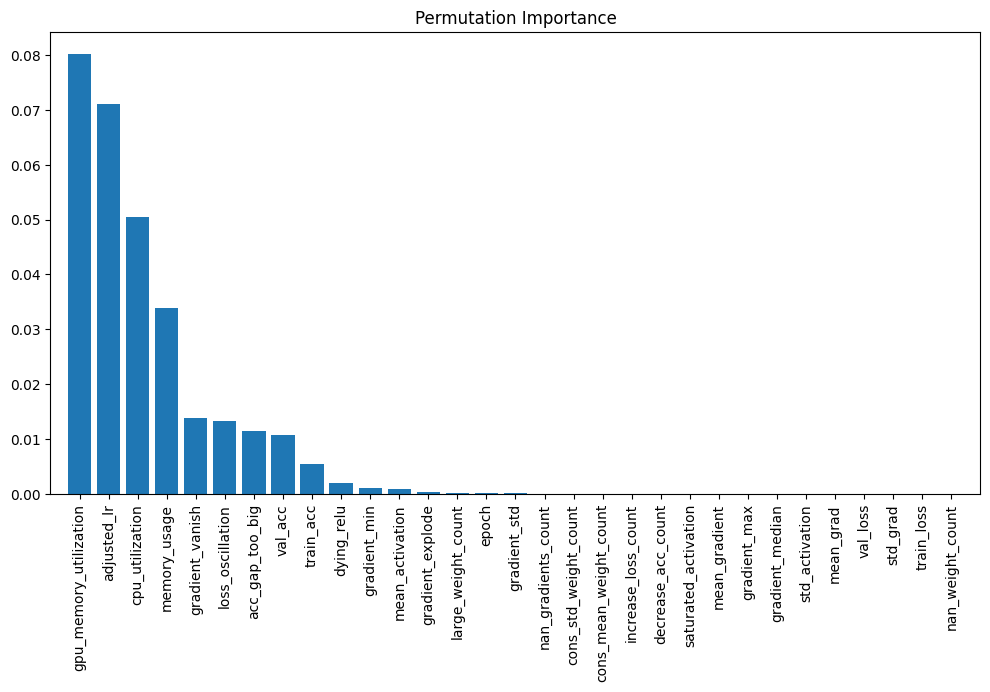

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
indices = result.importances_mean.argsort()[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Permutation Importance")
plt.bar(range(X_train.shape[1]), result.importances_mean[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


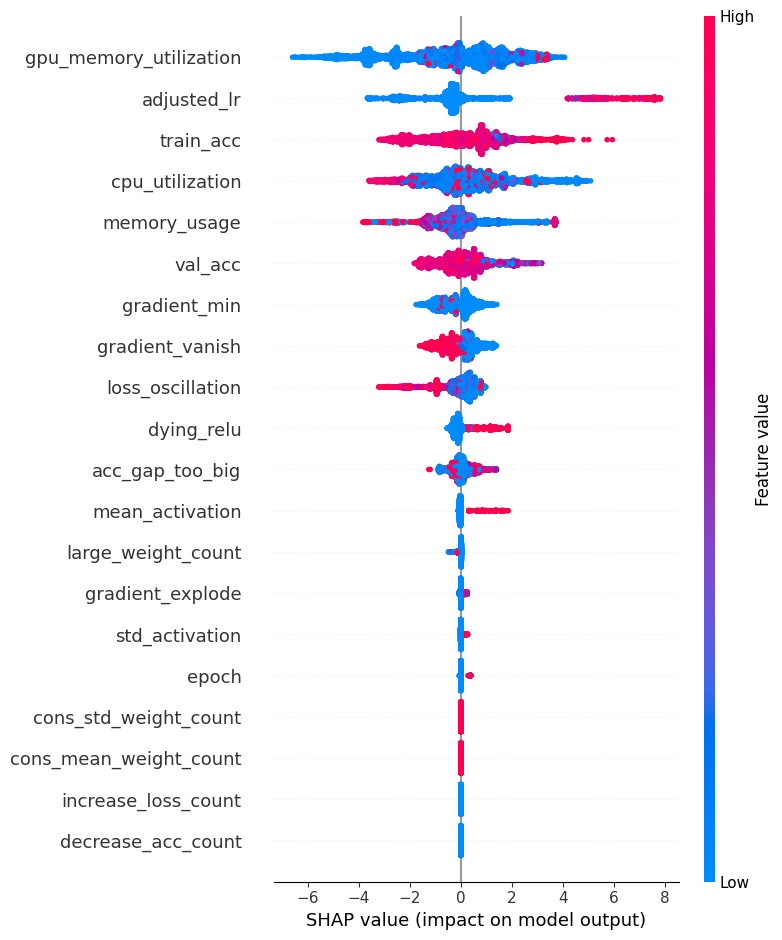

In [49]:
import shap
import xgboost as xgb

model = xgb.XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
feature_names = X.columns
shap.summary_plot(shap_values, X_train, feature_names=feature_names)


Feature ranking:
1. feature 23 (3.054909)
2. feature 0 (1.003447)
3. feature 2 (-0.721093)
4. feature 24 (0.519190)
5. feature 21 (-0.515063)
6. feature 9 (-0.512680)
7. feature 6 (0.456574)
8. feature 19 (0.387547)
9. feature 30 (-0.346202)
10. feature 5 (-0.326178)
11. feature 13 (0.308042)
12. feature 14 (0.308042)
13. feature 8 (0.304623)
14. feature 29 (0.275414)
15. feature 16 (0.250587)
16. feature 15 (0.250435)
17. feature 7 (-0.237951)
18. feature 22 (-0.165998)
19. feature 27 (-0.163458)
20. feature 1 (-0.141403)
21. feature 18 (0.127410)
22. feature 28 (-0.125169)
23. feature 25 (0.124559)
24. feature 3 (-0.120540)
25. feature 20 (0.116153)
26. feature 4 (0.065862)
27. feature 26 (0.054375)
28. feature 10 (-0.033874)
29. feature 12 (0.000000)
30. feature 11 (0.000000)
31. feature 17 (0.000000)


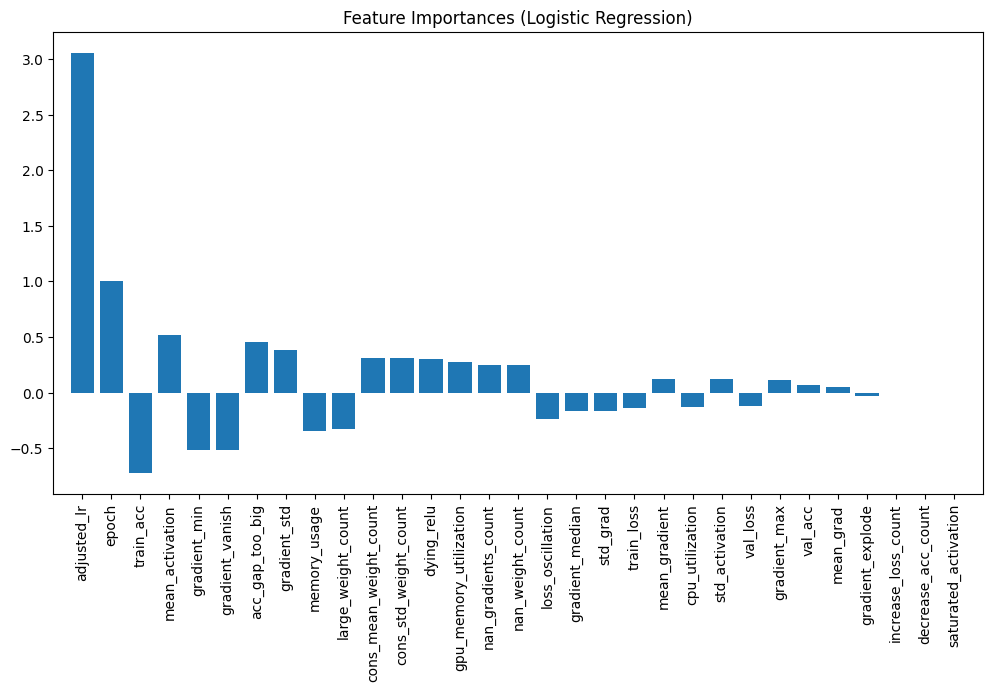

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
importance = model.coef_[0]
indices = np.argsort(np.abs(importance))[::-1]
print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importance[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Logistic Regression)")
plt.bar(range(X_train.shape[1]), importance[indices], align="center")
plt.xticks(range(X_train.shape[1]), feature_names, rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.show()


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
import lime
import lime.lime_tabular
from sklearn.linear_model import LogisticRegression

if len(y_train.shape) > 1 and y_train.shape[1] > 1:
    y_train = np.argmax(y_train, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)

if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=X.columns)
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)

print("Feature ranking:")
for f in range(X_train.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], result.importances_mean[indices[f]]))

feature_names = X.columns
feature_names = feature_names[indices]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=['class_0', 'class_1'],  
    mode='classification'
)

i = 0  
exp = explainer.explain_instance(X_test.iloc[i], model.predict_proba, num_features=10)
exp.show_in_notebook(show_all=False)


Feature ranking:
1. feature 23 (0.071137)
2. feature 0 (0.000097)
3. feature 2 (0.005539)
4. feature 24 (0.000875)
5. feature 21 (0.001166)
6. feature 9 (0.013800)
7. feature 6 (0.011467)
8. feature 19 (0.000097)
9. feature 30 (0.033819)
10. feature 5 (0.000097)
11. feature 13 (0.000000)
12. feature 14 (0.000000)
13. feature 8 (0.001944)
14. feature 29 (0.080175)
15. feature 16 (0.000000)
16. feature 15 (0.000000)
17. feature 7 (0.013217)
18. feature 22 (0.000000)
19. feature 27 (0.000000)
20. feature 1 (0.000000)
21. feature 18 (0.000000)
22. feature 28 (0.050437)
23. feature 25 (0.000000)
24. feature 3 (0.000000)
25. feature 20 (0.000000)
26. feature 4 (0.010690)
27. feature 26 (0.000000)
28. feature 10 (0.000292)
29. feature 12 (0.000000)
30. feature 11 (0.000000)
31. feature 17 (0.000000)


c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (co

Tree-based classifier

In [52]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from xgboost import XGBClassifier
from tqdm import tqdm
import xgboost as xgb


def run_models(X_train, X_test, y_train, y_test, verbose=True):
    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'DecisionTree': DecisionTreeClassifier(),
        'RandomForest': RandomForestClassifier(),
        'SVC': SVC(max_iter=1000),
        'KNeighbors': KNeighborsClassifier(),
        'MLP': MLPClassifier(max_iter=1000),
        'GradientBoosting': GradientBoostingClassifier(),
        'AdaBoost': AdaBoostClassifier(),
        'Bagging': BaggingClassifier(),
        'XGBoost': xgb.XGBClassifier()
    }
    
    results = {}
    
    for model_name, model in tqdm(models.items(), desc='Training Models', total=len(models)):
        model.fit(X_train, y_train)
        results[model_name] = model.score(X_test, y_test)
        
        if verbose:
            print(model_name, results[model_name])
            
    return results

In [53]:
# Run the models
results = run_models(X_train, X_test, y_train, y_test, verbose=False)
results

Training Models:  30%|███       | 3/10 [00:00<00:01,  6.55it/s]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Training Models:  70%|███████   | 7/10 [00:10<00:05,  1.95s/it]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
Training Models: 100%|██████████| 10/10 [00:11<00:00,  1.15s/it]


{'LogisticRegression': 0.7482993197278912,
 'DecisionTree': 0.9786200194363459,
 'RandomForest': 0.9873663751214772,
 'SVC': 0.8445092322643343,
 'KNeighbors': 0.9261418853255587,
 'MLP': 0.9319727891156463,
 'GradientBoosting': 0.9475218658892128,
 'AdaBoost': 0.8785228377065112,
 'Bagging': 0.9805636540330418,
 'XGBoost': 0.9902818270165209}

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from tqdm import tqdm
import xgboost as xgb

def run_models_classification_report(X_train, X_test, y_train, y_test, verbose=True):
    models = {
        'LogisticRegression': LogisticRegression(max_iter=1000),
        'DecisionTree': DecisionTreeClassifier(),
        'RandomForest': RandomForestClassifier(),
        'SVC': SVC(max_iter=1000),
        'KNeighbors': KNeighborsClassifier(),
        'MLP': MLPClassifier(max_iter=1000),
        'GradientBoosting': GradientBoostingClassifier(),
        'AdaBoost': AdaBoostClassifier(),
        'Bagging': BaggingClassifier(),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    }
    
    results = {}
    cv_results = {}

    for model_name, model in tqdm(models.items(), desc='Training Models', total=len(models)):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[model_name] = classification_report(y_test, y_pred, output_dict=True)
        
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)
        cv_results[model_name] = cv_scores
        
        if verbose:
            print(model_name)
            print("Classification Report:")
            print(classification_report(y_test, y_pred))
            print("Cross-Validation Scores:")
            print(cv_scores)
            print("Mean CV Score:", cv_scores.mean())
            print("Standard Deviation of CV Scores:", cv_scores.std())
            print()
            
    return results, cv_results

# Run the models
results, cv_results = run_models_classification_report(X_train, X_test, y_train, y_test, verbose=False)

for model_name in results.keys():
    print(model_name)
    print("Classification Report:")
    print(results[model_name])
    print("Cross-Validation Scores:")
    print(cv_results[model_name])
    print("Mean CV Score:", cv_results[model_name].mean())
    print("Standard Deviation of CV Scores:", cv_results[model_name].std())
    print()

Training Models:  30%|███       | 3/10 [00:00<00:01,  6.35it/s]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
Training Models:  70%|███████   | 7/10 [00:12<00:06,  2.24s/it]c:\Users\sigma\Documents\GitHub\ASE_2024\myenv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
Training Models: 100%|██████████| 10/10 [00:13<00:00,  1.32s/it]

LogisticRegression
{'0': {'precision': 0.7251655629139073, 'recall': 0.8248587570621468, 'f1-score': 0.771806167400881, 'support': 531.0}, '1': {'precision': 0.7811764705882352, 'recall': 0.6666666666666666, 'f1-score': 0.7193932827735645, 'support': 498.0}, 'accuracy': 0.7482993197278912, 'macro avg': {'precision': 0.7531710167510712, 'recall': 0.7457627118644068, 'f1-score': 0.7455997250872228, 'support': 1029.0}, 'weighted avg': {'precision': 0.752272882662999, 'recall': 0.7482993197278912, 'f1-score': 0.7464401649281857, 'support': 1029.0}}

DecisionTree
{'0': {'precision': 0.9758812615955473, 'recall': 0.9905838041431262, 'f1-score': 0.983177570093458, 'support': 531.0}, '1': {'precision': 0.9897959183673469, 'recall': 0.9738955823293173, 'f1-score': 0.9817813765182186, 'support': 498.0}, 'accuracy': 0.9825072886297376, 'macro avg': {'precision': 0.9828385899814471, 'recall': 0.9822396932362217, 'f1-score': 0.9824794733058383, 'support': 1029.0}, 'weighted avg': {'precision': 0.98

In [63]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
clf.fit(X_train, y_train)
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]
k = 20
X_train_selected = X_train.iloc[:, indices[:k]]
X_test_selected = X_test.iloc[:, indices[:k]]
print("Feature ranking:")
for f in range(X_train_selected.shape[1]):
    print("%d. feature %d (%f)" % (f + 1, indices[f], importances[indices[f]]))

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],  
    'max_features': ['sqrt', 'log2'] 
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True),
    param_grid=param_grid,
    cv=5, 
    verbose=2,
    n_jobs=-1
)
grid_search.fit(X_train_selected, y_train)
best_clf = grid_search.best_estimator_
y_pred = best_clf.predict(X_test_selected)
target_names = [str(cat) for cat in encoder.categories_[0]]

print(classification_report(y_test, y_pred, target_names=target_names))
print("OOB Score of Best Model: ", best_clf.oob_score_)


Feature ranking:
1. feature 29 (0.166730)
2. feature 28 (0.124247)
3. feature 23 (0.123479)
4. feature 2 (0.121814)
5. feature 30 (0.103176)
6. feature 4 (0.099273)
7. feature 7 (0.058247)
8. feature 9 (0.052710)
9. feature 6 (0.047726)
10. feature 8 (0.023587)
11. feature 5 (0.015575)
12. feature 21 (0.014328)
13. feature 10 (0.008572)
14. feature 24 (0.008094)
15. feature 25 (0.006228)
16. feature 19 (0.005908)
17. feature 0 (0.004649)
18. feature 20 (0.004104)
19. feature 18 (0.004027)
20. feature 3 (0.001624)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       531
           1       1.00      0.97      0.98       498

    accuracy                           0.99      1029
   macro avg       0.99      0.99      0.99      1029
weighted avg       0.99      0.99      0.99      1029

OOB Score of Best Model:  0.9895453440311208
